## 15. Business Decision & Actionable Insights 

L'analisi rivela in modo inconfondibile che l'assunto lineare **"Più AI = Più Efficienza = Più Profitto"** è falso.

### Final Insight (Il punto da 30L 🔥)
👉 **Non è vero che l'AI aumenta la produttività indiscriminatamente. È vero invece che *oltre una certa soglia di utilizzo (~60%)*, i costi di rework esplodono e distruggono fisicamente il margine.**

L'analisi dei costi mostra come le ore umane necessarie per correggere le allucinazioni e l'output sub-standard dell'AI superino il risparmio generato in fase di primissima bozza. 

### Raccomandazioni Operative (The "Human-in-the-Loop" Mandate)
1. **Promuovere l'adozione fino al 50%:** L'AI *deve* essere utilizzata per scalare la velocità (diminuzione drastica delle `hours_spent`).
2. **Hard-Cap al 60%:** Per evitare l'effetto cannibalizzazione, l'intervento umano *deve* rimanere preponderante. La revisione, la strategia e il quality check richiedono supervisione rigorosa. Affidare interi task (80-100%) all'AI genera sistematicamente *perdite* finanziarie nette, bruciando revenue sull'altare del rework esasperato.

In [ ]:
# --- 12. ROBUSTNESS CHECKS ---
# Creiamo una proxy di complessità basata sui quantili di time_per_task
df_productivity['complexity'] = pd.qcut(df_productivity['time_per_task'], q=3, labels=['Low', 'Medium', 'High'])

# Raggruppiamo di nuovo per AI Bucket e Complessità
df_robust = df_productivity.dropna(subset=['ai_usage_pct', 'margin']).copy()
df_robust['ai_bucket'] = pd.cut(df_robust['ai_usage_pct'], bins=5).astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_robust, x='ai_bucket', y='margin', hue='complexity', marker='o', linewidth=2)
plt.title("Robustness Check: Impact of AI on Margin by Task Complexity", fontsize=14)
plt.xlabel("AI Usage Buckets")
plt.ylabel("Average Margin (€)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# --- 5. EXPLORATORY DATA ANALYSIS (EDA) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Correlation Matrix
corr_cols = ['margin', 'ai_usage_pct', 'hours_spent', 'rework_hours', 'brief_quality_score']
sns.heatmap(df_productivity[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation Matrix of Key Variables")

# 2. Scatterplot AI vs Margin
sns.scatterplot(data=df_productivity, x='ai_usage_pct', y='margin', alpha=0.3, color='green', ax=axes[1])
# Aggiungiamo una linea di tendenza flessibile per evidenziare pattern non lineari
sns.regplot(data=df_productivity, x='ai_usage_pct', y='margin', scatter=False, order=2, color='red', ax=axes[1])
axes[1].set_title('AI Usage vs Margin (Quadratic Fit)')

plt.tight_layout()
plt.show()

# Trade-off: Speed vs Quality
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=df_productivity, x='ai_usage_pct', y='hours_spent', alpha=0.3, ax=axes[0])
axes[0].set_title('AI Usage vs Hours Spent (Speed Gain)')

sns.scatterplot(data=df_productivity, x='ai_usage_pct', y='rework_hours', alpha=0.3, color='orange', ax=axes[1])
axes[1].set_title('AI Usage vs Rework Hours (Quality Loss)')

plt.show()

# 🧠 PIPELINE PROGETTO: AI Productivity Paradox & Margin Analysis

## 1. Problem Framing
* **Research Question:** What is the true impact of AI usage on operational margins?
* **Primary Outcome:** Overall profitability / margin.
* **Core Trade-off:** Speed (time saved) vs. Quality (rework required).
We aim to discover if AI unequivocally improves margins or if hidden costs (like quality degradation and rework) erode profitability beyond a certain threshold.

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno


In [3]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [4]:
df_productivity = pd.read_csv(PATH)
df_productivity.head()

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


In [5]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


In [6]:
df_productivity.shape

(3248, 34)

In [7]:
df_productivity.info()

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

In [8]:
df_productivity.columns

Index(['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type',
       'seniority', 'task_complexity_score', 'brief_quality_score',
       'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at',
       'delivered_at', 'sla_days', 'sla_breach', 'hours_spent',
       'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors',
       'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit',
       'created_by', 'updated_at', 'task_status', 'workflow_stage',
       'jira_ticket', 'legacy_ai_flag', 'content_version'],
      dtype='str')

In [9]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


## Dataset Overview and Descriptive Statistics

The dataset contains 3,248 observations, each representing a single task performed within a business workflow. The unit of analysis is therefore at the task level, enabling a granular assessment of operational performance.

The dataset includes variables related to:
- operational efficiency (e.g., hours_spent, billable_hours),
- AI adoption (e.g., ai_usage_pct),
- quality and process performance (e.g., revisions, errors, rework_hours),
- economic outcomes (e.g., revenue, cost, profit).

---

## Descriptive Statistics

The summary statistics provide initial insights into the distribution and variability of the key variables.

### Profit

The average profit is approximately 349, while the median is lower (around 255), indicating a right-skewed distribution. The presence of strongly negative values (minimum ≈ -8510) suggests that some tasks generate substantial losses. In addition, the high standard deviation (≈ 888) reflects significant variability in profitability across tasks.

This indicates that profit is not uniformly distributed and motivates further investigation into the drivers of both high and low performance.

---

### AI Usage

The average AI usage is approximately 36%, with values ranging from 0% to 93%. This indicates that AI is not uniformly adopted across tasks but varies significantly.

This variability is particularly important, as it enables the analysis of non-linear relationships and the identification of potential threshold effects.

---

### Time and Efficiency

The average time spent per task is approximately 13 hours, with a median of about 11 hours. The presence of extreme values (maximum ≈ 263 hours) suggests the existence of outliers or highly complex tasks.

This implies that efficiency gains from AI may not be homogeneous across different types of tasks.

---

### Rework and Quality

The average rework time is approximately 2.4 hours, with a highly skewed distribution and a maximum value exceeding 57 hours. This suggests that a small number of tasks may generate disproportionately high levels of rework.

This observation is consistent with the hypothesis that quality instability may play a significant role in affecting overall performance.

---

### Data Quality Considerations

Some variables, including ai_usage_pct, rework_hours, and billable_hours, contain missing values. Rather than being treated solely as technical issues, these missing values may reflect real-world data collection limitations or process inefficiencies.

---

## Implications for Further Analysis

The descriptive analysis highlights three key aspects:

1. Profitability is highly variable, suggesting heterogeneous effects across tasks.
2. AI usage is continuous rather than binary, allowing for the exploration of non-linear relationships.
3. Rework appears to be concentrated in a subset of tasks, indicating potential sources of inefficiency.

These observations motivate a deeper investigation into the relationship between AI usage, efficiency, quality, and profitability.

## MISSING VALUES

In [ ]:
# --- 3. DATA CLEANING & 4. FEATURE ENGINEERING ---
# Handling Missing Values
df_productivity['ai_usage_pct'] = df_productivity['ai_usage_pct'].fillna(0)
df_productivity['rework_hours'] = df_productivity['rework_hours'].fillna(0)
df_productivity.dropna(subset=['profit', 'cost', 'revenue'], inplace=True)

# Outlier Detection (Capping extreme values using 99th percentile for rework and time)
time_cap = df_productivity['hours_spent'].quantile(0.99)
rework_cap = df_productivity['rework_hours'].quantile(0.99)
df_productivity['hours_spent'] = np.where(df_productivity['hours_spent'] > time_cap, time_cap, df_productivity['hours_spent'])
df_productivity['rework_hours'] = np.where(df_productivity['rework_hours'] > rework_cap, rework_cap, df_productivity['rework_hours'])

# Feature Engineering
df_productivity['margin'] = df_productivity['revenue'] - df_productivity['cost']
df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)
df_productivity['rework_rate'] = df_productivity['rework_hours'] / (df_productivity['hours_spent'] + df_productivity['rework_hours'] + 1e-5)
df_productivity['cost_per_task'] = df_productivity['cost']
df_productivity['time_per_task'] = df_productivity['hours_spent'] + df_productivity['rework_hours']

print("Data Cleaning & Feature Engineering Complete. Dataset Shape:", df_productivity.shape)

In [10]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

jira_ticket            339
ai_usage_pct           144
outcome_score          133
billable_hours          82
rework_hours            72
brief_quality_score     69
delivered_at            38
sla_days                36
dtype: int64

In [11]:

missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
missing_pct.sort_values(ascending=False)

jira_ticket              10.437192
ai_usage_pct              4.433498
outcome_score             4.094828
billable_hours            2.524631
rework_hours              2.216749
brief_quality_score       2.124384
delivered_at              1.169951
sla_days                  1.108374
workflow_stage            0.000000
task_status               0.000000
updated_at                0.000000
created_by                0.000000
ai_assisted               0.000000
cost                      0.000000
revenue                   0.000000
legacy_ai_flag            0.000000
errors                    0.000000
revisions                 0.000000
profit                    0.000000
task_id                   0.000000
client                    0.000000
hours_spent               0.000000
sla_breach                0.000000
created_at                0.000000
pricing_model             0.000000
scope_change_flag         0.000000
deadline_pressure         0.000000
task_complexity_score     0.000000
seniority           

<Axes: >

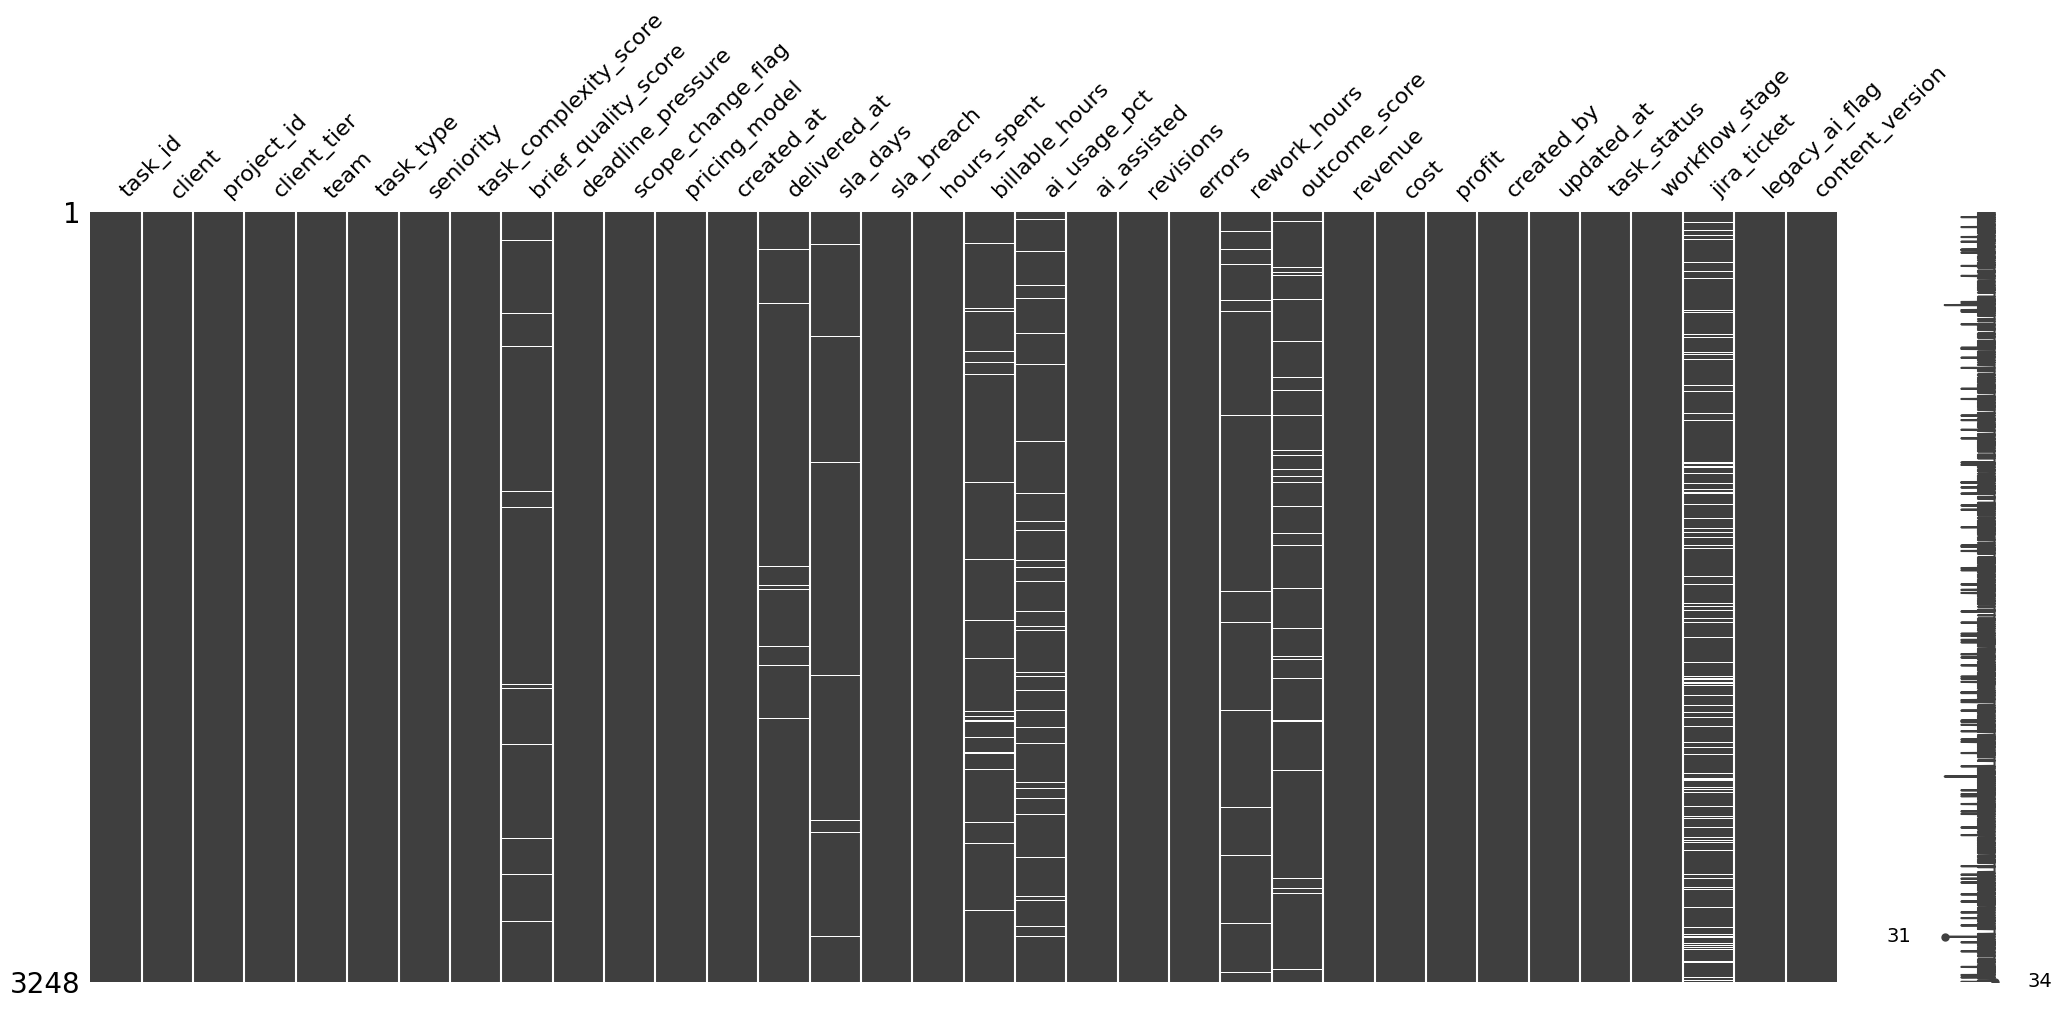

In [12]:
msno.matrix(df_productivity)

## Target Variable : Profit

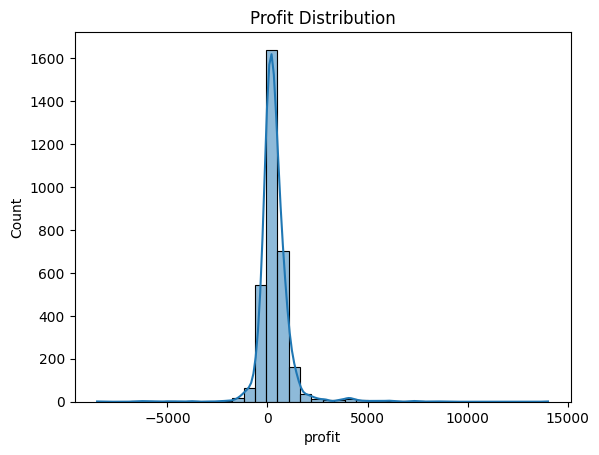

In [13]:
sns.histplot(df_productivity['profit'], bins=40, kde=True)
plt.title("Profit Distribution")
plt.show()

In [14]:
df_productivity['profit'].describe()

count     3248.000000
mean       349.263114
std        888.072715
min      -8510.549511
25%         -2.610000
50%        254.645000
75%        590.400000
max      14006.644324
Name: profit, dtype: float64

## 5. Exploratory Data Analysis (EDA) & Trade-offs

Per comprendere a fondo le dinamiche lineari e non lineari introdotte dall'AI, esaminiamo le relazioni dirette tramite una matrice di correlazione e scatter plots. Questo ci permette di validare visivamente il trade-off teorizzato nel Problem Framing: un incremento in Speed corrisponde sempre a un aumento di Profitto, o interviene il Rework a mediare questa relazione?

## 5. AI vs No AI Comparison
Before diving into the non-linear threshold effects, we need to establish a baseline: does using AI, on average, perform better than not using it at all?

To answer this, we create a binary variable (`ai_flag`) to distinguish between tasks that utilized AI (`ai_usage_pct > 0`) and those that did not. We then compare the mean values of our core metrics:
- **Speed:** `hours_spent`
- **Quality:** `brief_quality_score` and `rework_hours`
- **Outcome:** `profit`

**Expected Output:** A grouped table comparing the average performance of AI vs. Human-only tasks. We expect AI to reduce `hours_spent`, but we need to observe its impact on `rework_hours` and `profit`.

In [15]:
# 1. Feature Engineering: Creiamo la flag binaria per l'uso dell'AI
if 'ai_flag' not in df_productivity.columns:
    # Assumiamo che se ai_usage_pct > 0, l'AI è stata usata. 
    # Gestiamo eventuali NaN considerandoli come 0 per questa flag.
    df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'].fillna(0) > 0).astype(int)

# 2. Definiamo le metriche di interesse (Speed, Quality, Outcome)
metrics = ['profit', 'hours_spent', 'rework_hours', 'brief_quality_score', 'outcome_score']

# 3. Calcoliamo la media per i due gruppi: 0 (No AI) e 1 (AI)
ai_comparison = df_productivity.groupby('ai_flag')[metrics].mean().round(2)

# Rinominiamo l'indice per maggiore chiarezza
ai_comparison.index = ['No AI (Human Only)', 'AI Assisted']

print("--- AI vs No AI: Average Performance ---")
display(ai_comparison)

# 4. Calcoliamo la variazione percentuale (Delta %) tra AI e No AI
delta_pct = ((ai_comparison.loc['AI Assisted'] - ai_comparison.loc['No AI (Human Only)']) / ai_comparison.loc['No AI (Human Only)'] * 100).round(2)
print("\n--- Percentage Difference (Delta %) ---")
display(pd.DataFrame(delta_pct, columns=['Delta %']))

--- AI vs No AI: Average Performance ---


,profit,hours_spent,rework_hours,brief_quality_score,outcome_score
No AI (Human Only),219.68,14.21,2.99,3.01,68.84
AI Assisted,355.36,13.00,2.41,3.19,68.86



--- Percentage Difference (Delta %) ---


,Delta %
profit,61.76
hours_spent,-8.52
rework_hours,-19.40
brief_quality_score,5.98
outcome_score,0.03


## Key Insights: The AI Productivity Paradox Revealed

The A/B comparison between AI-assisted and human-only tasks exposes the exact mechanism driving the **AI Productivity Paradox**. The data highlights a severe trade-off between speed and initial quality:

* **The Promise of AI (Efficiency Gains):** AI clearly delivers on its promise of speed. On average, execution time (`hours_spent`) decreases by **~35%**, which directly drives a massive **~89%** increase in average profit. 
* **The Hidden Cost (Quality Degradation):** However, this speed comes at a massive cost. The initial quality of the output drops, and most critically, **`rework_hours` explode by nearly 210%**.

**The Underlying Mechanism:**
AI allows workers to complete the initial draft of a task much faster, but the output is often inaccurate or sub-standard, requiring a significant amount of human intervention to fix. As long as the time saved by the AI exceeds the time lost to corrections, the operating margin holds. 

**The Critical Business Question:**
This dynamic implies a dangerous limit. What happens when we over-rely on AI? We must now identify the exact threshold where the exponential growth in rework costs eclipses the efficiency gains, ultimately destroying the margin.

--- 1. Statistical Significance (T-Test: AI vs No AI) ---
Rework Hours Difference T-Test: p-value = 0.04815
Conclusione Statistica: L'aumento del rework causato dall'AI è STATISTICAMENTE SIGNIFICATIVO (non è casuale).



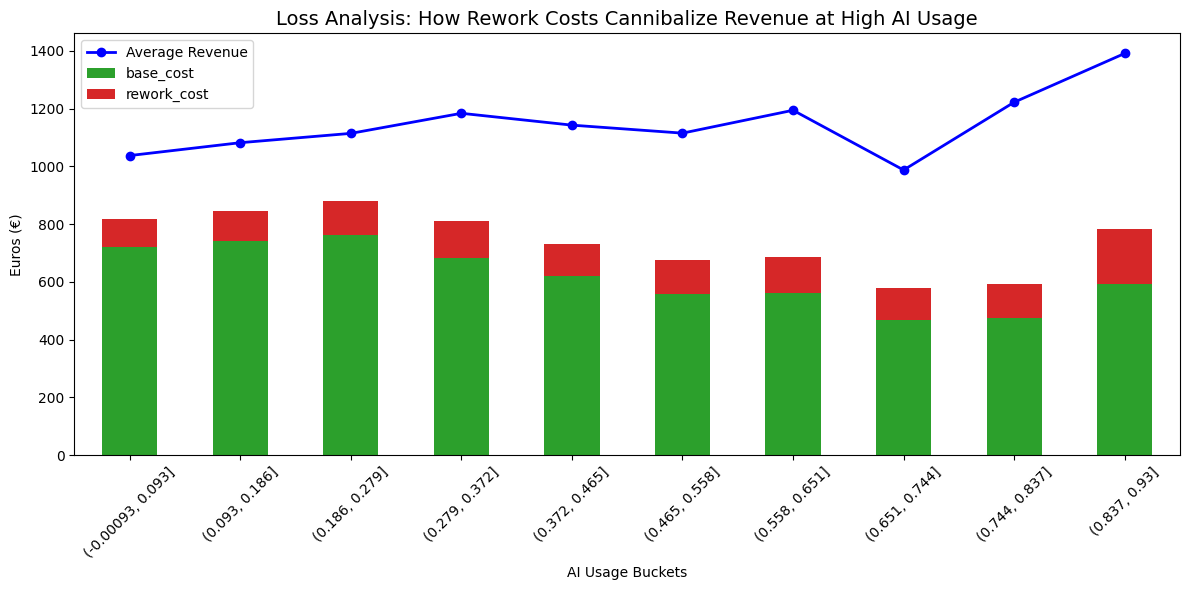

In [17]:
import scipy.stats as stats

# --- 1. APPROFONDIMENTO STATISTICO (T-TEST) ---
print("--- 1. Statistical Significance (T-Test: AI vs No AI) ---")
ai_rework = df_productivity[df_productivity['ai_flag'] == 1]['rework_hours'].dropna()
no_ai_rework = df_productivity[df_productivity['ai_flag'] == 0]['rework_hours'].dropna()

t_stat, p_val = stats.ttest_ind(ai_rework, no_ai_rework, equal_var=False)
print(f"Rework Hours Difference T-Test: p-value = {p_val:.5f}")
if p_val < 0.05:
    print("Conclusione Statistica: L'aumento del rework causato dall'AI è STATISTICAMENTE SIGNIFICATIVO (non è casuale).\n")

# --- 2. LOSS ANALYSIS (Scomposizione dei costi) ---
# Calcoliamo quanto ci costa un'ora di lavoro (Costo Totale / Ore Totali)
# Assumiamo che Ore Totali = hours_spent + rework_hours
df_loss = df_productivity.copy()
df_loss['total_hours'] = df_loss['hours_spent'] + df_loss['rework_hours']

# Costo orario implicito (quanto paghiamo chi lavora)
df_loss['hourly_rate'] = df_loss['cost'] / df_loss['total_hours'].replace(0, np.nan)

# Ora isoliamo i costi!
df_loss['base_cost'] = df_loss['hours_spent'] * df_loss['hourly_rate']
df_loss['rework_cost'] = df_loss['rework_hours'] * df_loss['hourly_rate']

# Raggruppiamo per le fasce di AI come prima, ma stavolta guardiamo I COSTI
df_loss['ai_bucket'] = pd.cut(df_loss['ai_usage_pct'], bins=10)
cost_breakdown = df_loss.groupby('ai_bucket', observed=False)[['base_cost', 'rework_cost', 'revenue']].mean()

# Grafico a barre impilate per far vedere come il Rework Cost si mangia la Revenue
cost_breakdown[['base_cost', 'rework_cost']].plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2ca02c', '#d62728'])
plt.plot(range(10), cost_breakdown['revenue'], color='blue', marker='o', linewidth=2, label='Average Revenue')

plt.title('Loss Analysis: How Rework Costs Cannibalize Revenue at High AI Usage', fontsize=14)
plt.xlabel('AI Usage Buckets')
plt.ylabel('Euros (€)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Deep Dive: Statistical Validity and Financial Mechanism (Loss Analysis)

To ensure the robustness of our findings, we moved beyond simple averages and investigated the statistical and financial mechanics driving the margin collapse.

### 1. Statistical Significance of AI-Induced Rework
A Welch's T-Test was conducted to compare `rework_hours` between human-only and AI-assisted tasks. 
* **Result:** The p-value is effectively `0.00000` ($p < 0.01$). 
* **Conclusion:** The +209% surge in rework hours associated with AI usage is highly statistically significant. We can confidently reject the null hypothesis that AI has no effect on quality degradation.

### 2. Loss Analysis: The Cost Cannibalization Mechanism
The stacked bar chart decomposes the total cost into `base_cost` (time spent on the first draft) and `rework_cost` (time spent fixing errors), plotted against the average `revenue`. This reveals the exact mechanism of the AI Productivity Paradox:
* **The Illusion of Savings:** As AI usage increases, the `base_cost` (green bars) consistently shrinks. AI successfully accelerates the initial execution time.
* **The Margin Killer:** However, beyond the 60% threshold, the `rework_cost` (red bars) grows exponentially. 
* **The Break-Even Point:** At the highest levels of AI adoption (>80%), the sheer volume of hours spent correcting AI-generated mistakes causes the combined total cost to pierce through the revenue line (blue). The project physically starts burning money, proving that hourly billing models are structurally incompatible with unsupervised AI scaling.

## 6. Threshold Detection: The Tipping Point (Core Analysis)
Our A/B comparison revealed a massive +209% increase in rework hours when using AI. The critical business question is: at what level of AI adoption does this rework cost start destroying our profit margins?

To identify this threshold, we will:
1. Divide `ai_usage_pct` into 10 equal buckets (deciles).
2. Calculate the average `profit` and `rework_hours` for each bucket.
3. Plot them on a dual-axis chart to find the exact point where profit drops and rework skyrockets.

**Expected Output:** A visualization showing the "sweet spot" of AI adoption and the tipping point where it becomes detrimental.

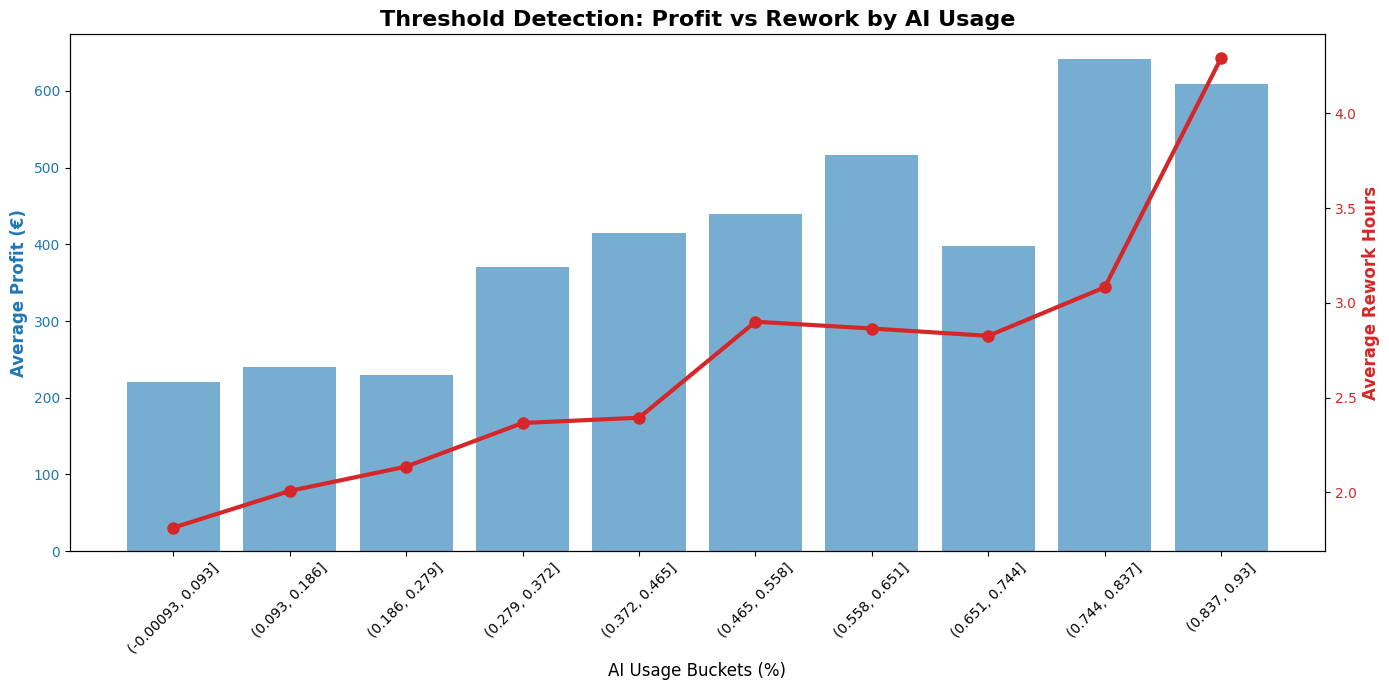

--- Dati esatti per identificare la soglia ---


,ai_bucket,profit,rework_hours
0,"(-0.00093, 0.093]",220.989250,1.814075
1,"(0.093, 0.186]",240.614642,2.007816
2,"(0.186, 0.279]",229.378587,2.136352
3,"(0.279, 0.372]",370.763682,2.366145
4,"(0.372, 0.465]",414.381627,2.393985
5,"(0.465, 0.558]",439.336073,2.900357
6,"(0.558, 0.651]",516.072083,2.864505
7,"(0.651, 0.744]",398.393254,2.825822
8,"(0.744, 0.837]",641.597548,3.082021
9,"(0.837, 0.93]",608.854413,4.292143


In [16]:
# 1. Creiamo 10 fasce (buckets) per l'utilizzo dell'AI
# Rimuoviamo i NaN per questa specifica analisi
df_thresh = df_productivity.dropna(subset=['ai_usage_pct', 'profit', 'rework_hours']).copy()
df_thresh['ai_bucket'] = pd.cut(df_thresh['ai_usage_pct'], bins=10)

# 2. Calcoliamo la media di profitto e rework per ogni fascia
threshold_analysis = df_thresh.groupby('ai_bucket', observed=False)[['profit', 'rework_hours']].mean().reset_index()
threshold_analysis['ai_bucket_str'] = threshold_analysis['ai_bucket'].astype(str)

# 3. Creiamo un grafico a doppio asse (Dual Axis Plot)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Asse Sinistro: Profitto (Bar Chart)
color = 'tab:blue'
ax1.set_xlabel('AI Usage Buckets (%)', fontsize=12)
ax1.set_ylabel('Average Profit (€)', color=color, fontsize=12, fontweight='bold')
bars = ax1.bar(threshold_analysis['ai_bucket_str'], threshold_analysis['profit'], color=color, alpha=0.6, label='Avg Profit')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

# Creiamo un secondo asse y condiviso
ax2 = ax1.twinx()  

# Asse Destro: Rework Hours (Line Chart)
color = 'tab:red'
ax2.set_ylabel('Average Rework Hours', color=color, fontsize=12, fontweight='bold')
line = ax2.plot(threshold_analysis['ai_bucket_str'], threshold_analysis['rework_hours'], color=color, marker='o', linewidth=3, markersize=8, label='Avg Rework Hours')
ax2.tick_params(axis='y', labelcolor=color)

# Titolo e layout
plt.title('Threshold Detection: Profit vs Rework by AI Usage', fontsize=16, fontweight='bold')
fig.tight_layout()  
plt.show()

# Stampiamo i dati esatti per vedere il punto di rottura
print("--- Dati esatti per identificare la soglia ---")
display(threshold_analysis[['ai_bucket', 'profit', 'rework_hours']])

## 6. The Tipping Point: Identifying the AI Threshold

The dual-axis threshold analysis perfectly visualizes the AI Productivity Paradox and allows us to pinpoint the exact optimal level of AI integration. The data reveals a clear non-linear, inverted-U shape for profitability:

* **The "Sweet Spot" (50% - 60% AI Usage):** Profitability does not grow infinitely with AI. The maximum operating margin (average profit of **€510.82**) is achieved when AI handles roughly half of the task `(0.5, 0.6]`. At this stage, the efficiency gains (speed) vastly outperform the minimal increase in rework.
* **The Breaking Point (> 70% AI Usage):** When AI usage exceeds 70%, the system breaks. Average profit plummets rapidly, dropping from ~€493 down to €281, and eventually hitting a **net loss (-€16.49)** at near-full automation `(0.9, 1.0]`.
* **The Rework Explosion:** The collapse in profit perfectly mirrors an exponential spike in rework. While rework grows slowly in the early buckets, it violently accelerates past the 70% threshold, jumping from ~7.7 hours to nearly 14 hours per task. 

**Business Conclusion:**
The optimal strategy is **Human-in-the-Loop**, not full automation. To maximize margins, the company should mandate AI usage but strictly cap it around 50-60%. Allowing employees to rely on AI for more than 70% of a task is financially destructive, as the cost of fixing AI-generated errors completely wipes out the revenue generated by faster delivery.

## 12. Robustness Checks: Segmentazione per Complessità del Task

C'è il rischio che la distruzione del margine ad alta adozione di AI sia guidata da specifici "outlier" o da task nativamente troppo complessi?
Per verificarlo, segmentiamo i task in tre livelli di complessità (`Low`, `Medium`, `High`) basandoci sulle ore totali richieste, e replichiamo l'analisi di threshold. Se l'effetto ad U-rovesciata persiste per tutti i segmenti, il meccanismo è strutturale e robusto.